# LFYKI1101 - Capteurs, Actionneurs et Instrumentation
## Labo ATD - Mars 2026
### Analyse Thermique Différentielle (ATD) - Transitions de phase du gallium

**Notebook template** basé sur l'énoncé du labo.

- Étudiant : ...
- Groupe : ...
- Date : ...

---

## 1. Contexte expérimental

Le gallium (Ga, Z = 31) est un métal dont le point de fusion se situe légèrement au-dessus de la température ambiante (**T_f = 29.76 °C**).  
Le montage expérimental repose sur le principe de l'**Analyse Thermique Différentielle (ATD)**, avec deux capteurs TMP117 :

- **T1** : capteur de référence
- **T2** : capteur en contact thermique avec l'échantillon de gallium
- **Signal différentiel** : **ΔT = T1 - T2**

Le cycle expérimental comporte une **chauffe** puis un **refroidissement**.

---

## 2. Questions


In [1]:
# Imports de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# À adapter avec le vrai nom de votre fichier CSV
csv_path = "tmp117_log_labo_6mars.csv"


## 2.1. Prise en main des données

### Q1. Chargez le fichier CSV avec pandas. Affichez les premières lignes et vérifiez les types de données. Combien de points de mesure le fichier contient-il ? Quelle est la durée totale de l’expérience ?

In [2]:
# Q1 - Chargement des données
df = pd.read_csv(csv_path)

# Aperçu
display(df.head())

# Types
print(df.dtypes)

# Nombre de points
n_points = len(df)
print("Nombre de points :", n_points)

# Durée totale
duree_totale = df["Elapsed_Time_s"].iloc[-1] - df["Elapsed_Time_s"].iloc[0]
print("Durée totale de l'expérience [s] :", duree_totale)


,Elapsed_Time_s,Timestamp,T1_C,T2_C,Skew_ms,Delta_T_C
0,0.000,2026-03-06T12:07:31.375616,-9.5391,-9.3125,0.854,-0.2266
1,0.225,2026-03-06T12:07:31.600212,-9.5313,-9.3047,0.854,-0.2266
2,0.468,2026-03-06T12:07:31.843381,-9.5234,-9.3047,0.824,-0.2188
3,0.708,2026-03-06T12:07:32.083552,-9.5234,-9.2969,0.854,-0.2266
4,0.946,2026-03-06T12:07:32.321221,-9.5156,-9.3047,0.885,-0.2109


Elapsed_Time_s    float64
Timestamp             str
T1_C              float64
T2_C              float64
Skew_ms           float64
Delta_T_C         float64
dtype: object
Nombre de points : 4295
Durée totale de l'expérience [s] : 1016.199


**Réponse / interprétation :**

- Nombre de points : ...
- Durée totale : ...
- Commentaire sur les types de données : ...


### Q2. Calculez l’intervalle d’échantillonnage moyen et son écart-type à partir de la colonne Elapsed_Time_s. Comparez avec la fréquence d’échantillonnage nominale de 4 Hz. La mesure est-elle régulière ? Que révèle la colonne Skew_ms sur la synchronisation des deux capteurs ?

Intervalle moyen [s] : 0.23665556590591522
Écart-type de dt [s] : 0.009783583920006247
Fréquence moyenne [Hz] : 4.225550310519888

Résumé de Skew_ms :


count    4295.0000
mean        0.8635
std         0.0677
min         0.8240
25%         0.8540
50%         0.8540
75%         0.8540
max         2.1060
Name: Skew_ms, dtype: float64

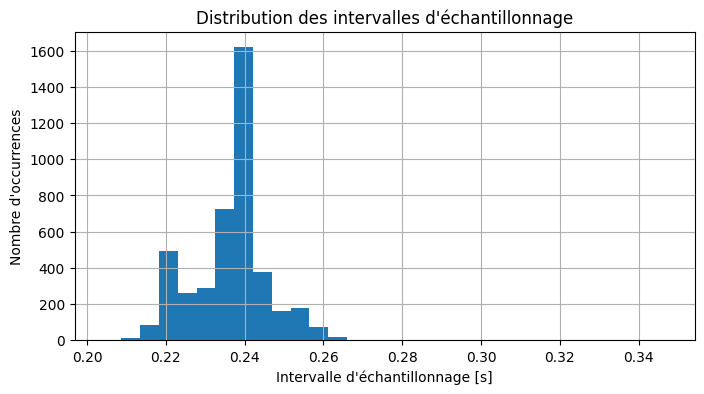

In [3]:
# Q2 - Analyse de l'échantillonnage
dt = df["Elapsed_Time_s"].diff().dropna()

dt_moyen = dt.mean()
dt_std = dt.std()

f_moyenne = 1 / dt_moyen

print("Intervalle moyen [s] :", dt_moyen)
print("Écart-type de dt [s] :", dt_std)
print("Fréquence moyenne [Hz] :", f_moyenne)

# Analyse simple de la colonne Skew_ms
print("\nRésumé de Skew_ms :")
display(df["Skew_ms"].describe())

# Histogramme optionnel
plt.figure(figsize=(8,4))
plt.hist(dt, bins=30)
plt.xlabel("Intervalle d'échantillonnage [s]")
plt.ylabel("Nombre d'occurrences")
plt.title("Distribution des intervalles d'échantillonnage")
plt.grid(True)
plt.show()


**Réponse / interprétation :**

- Intervalle moyen : ...
- Écart-type : ...
- Fréquence nominale attendue : 4 Hz -> période de 0.25 s
- Régularité de la mesure : ...
- Interprétation de `Skew_ms` : ...


## 2.2. Visualisation et identification des régimes

### Q3. Tracez T1(t) et T2(t) sur le même graphe (axes légendés, unités). Identifiez et délimitez visuellement les deux régimes de l’expérience : chauffe et refroidissement.

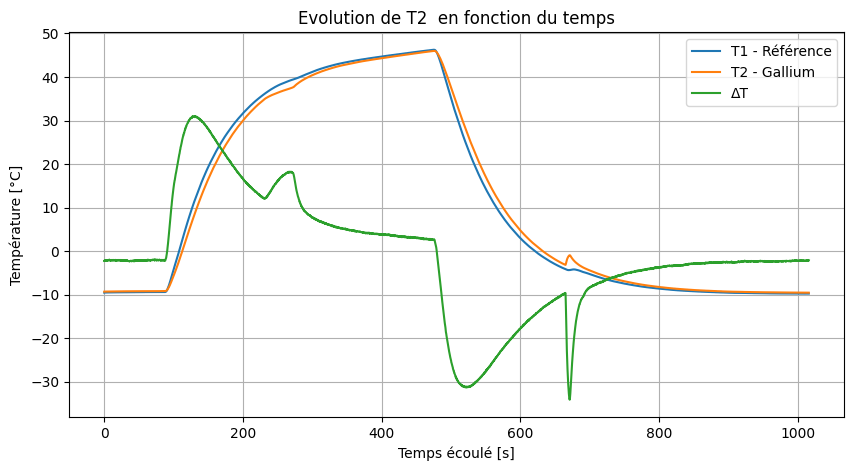

In [4]:
# Q3 - Tracé de T1(t) et T2(t)
plt.figure(figsize=(10,5))
plt.plot(df["Elapsed_Time_s"], df["T1_C"], label="T1 - Référence")
plt.plot(df["Elapsed_Time_s"], df["T2_C"], label="T2 - Gallium")
plt.plot(df["Elapsed_Time_s"], df["Delta_T_C"] * 10, label="ΔT")
plt.xlabel("Temps écoulé [s]")
plt.ylabel("Température [°C]")
plt.title("Evolution de T2  en fonction du temps")
plt.legend()
plt.grid(True)
plt.show()

# Option : estimer visuellement l'instant de bascule chauffe -> refroidissement
# t_bascule = ...


**Réponse / interprétation :**

- Régime de chauffe : de ... s à ... s
- Régime de refroidissement : de ... s à ... s
- Justification visuelle : ...


### Q4. Tracez ΔT(t) = T1(t) - T2(t) en fonction du temps. Décrivez qualitativement l’allure de la courbe. Où se situent les anomalies les plus marquées ?

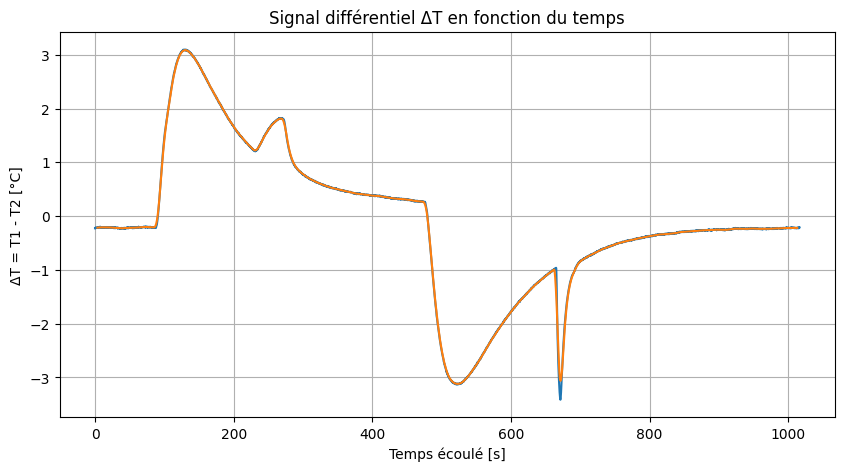

In [5]:
# Q4 - Tracé de Delta_T(t)
df["Delta_T_smooth"] = df["Delta_T_C"].rolling(window=30, center=True).mean()
plt.figure(figsize=(10,5))
plt.plot(df["Elapsed_Time_s"], df["Delta_T_C"], label="ΔT brut")
plt.plot(df["Elapsed_Time_s"], df["Delta_T_smooth"], label="ΔT lissé")
plt.xlabel("Temps écoulé [s]")
plt.ylabel("ΔT = T1 - T2 [°C]")
plt.title("Signal différentiel ΔT en fonction du temps")
plt.grid(True)
plt.show()


**Réponse / interprétation :**

- Allure générale : ...
- Anomalies principales observées vers ... s et ... s
- Lien possible avec fusion / solidification : ...


## 2.3. Principe physique de l’ATD

### Q5. Lors de la fusion du gallium, T2 absorbe la chaleur latente et sa montée en température ralentit par rapport à T1. Expliquez, à partir d’un bilan enthalpique, pourquoi ΔT = T1 - T2 devient positif à la fusion et négatif à la solidification. Schématisez la situation.

**Réponse théorique (à compléter) :**

Rédiger ici le bilan enthalpique et l'explication physique.

- À la fusion : ...
- À la solidification : ...
- Schéma / explication qualitative : ...


### Q6. Quel est l’avantage de mesurer ΔT plutôt que T2 seul pour détecter une transition de phase ? En quoi ce principe est-il analogue à celui d’une DSC (Differential Scanning Calorimetry) utilisée en recherche ?

**Réponse théorique (à compléter) :**

- Avantage du signal différentiel : ...
- Comparaison avec la DSC : ...


## 2.4. Extraction des grandeurs caractéristiques

### Q7. À partir de la courbe T2(t), estimez la température de fusion du gallium. Comparez avec la valeur tabulée (Tf = 29.76°C) et calculez l’écart relatif. Discutez les sources d’incertitude (résolution du capteur, contact thermique, vitesse de chauffe).

Temps estimé : 268.59 s
Température de fusion estimée : 39.46 °C


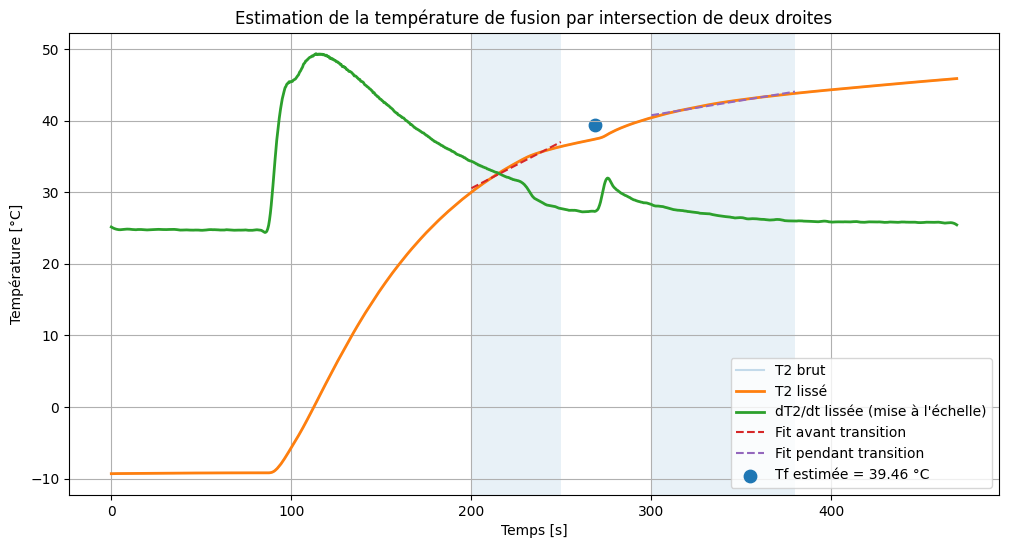

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# =========================
# 1) Données
# =========================
t = df["Elapsed_Time_s"].to_numpy()
T2 = df["T2_C"].to_numpy()

# =========================
# 2) Phase de chauffe
# =========================
mask_heat = t < 470
t_heat = t[mask_heat]
T2_heat = T2[mask_heat]

# =========================
# 3) Lissage de T2
# =========================
window = 31   # impair
poly = 3
T2_smooth = savgol_filter(T2_heat, window_length=window, polyorder=poly)

# =========================
# 4) Fenêtres choisies à la main
#    avant fusion et zone modifiée par la fusion
# =========================
pre_mask = (t_heat >= 200) & (t_heat <= 250)
trans_mask = (t_heat >= 300) & (t_heat <= 380)

t_pre = t_heat[pre_mask]
T_pre = T2_smooth[pre_mask]

t_trans = t_heat[trans_mask]
T_trans = T2_smooth[trans_mask]

# =========================
# 5) Ajustement linéaire
# =========================
a1, b1 = np.polyfit(t_pre, T_pre, 1)
a2, b2 = np.polyfit(t_trans, T_trans, 1)

# Intersection
t_f = (b2 - b1) / (a1 - a2)
T_f = a1 * t_f + b1

print(f"Temps estimé : {t_f:.2f} s")
print(f"Température de fusion estimée : {T_f:.2f} °C")

# =========================
# 6) Dérivée lissée pour visualisation
# =========================
dT2_dt = np.gradient(T2_smooth, t_heat)
dT2_dt_smooth = savgol_filter(dT2_dt, window_length=31, polyorder=3)

# mise à l’échelle juste pour affichage sur le même graphe
dT2_scaled = dT2_dt_smooth * 50 + np.mean(T2_smooth)

# =========================
# 7) Tracé
# =========================
plt.figure(figsize=(12,6))

plt.plot(t_heat, T2_heat, alpha=0.25, label="T2 brut")
plt.plot(t_heat, T2_smooth, linewidth=2, label="T2 lissé")
plt.plot(t_heat, dT2_scaled, linewidth=2, label="dT2/dt lissée (mise à l'échelle)")

# droites ajustées
tt1 = np.linspace(t_pre.min(), t_pre.max(), 100)
tt2 = np.linspace(t_trans.min(), t_trans.max(), 100)

plt.plot(tt1, a1*tt1 + b1, "--", label="Fit avant transition")
plt.plot(tt2, a2*tt2 + b2, "--", label="Fit pendant transition")

# point d'intersection
plt.scatter(t_f, T_f, s=80, label=f"Tf estimée = {T_f:.2f} °C")

# zones utilisées
plt.axvspan(t_pre.min(), t_pre.max(), alpha=0.1)
plt.axvspan(t_trans.min(), t_trans.max(), alpha=0.1)

plt.xlabel("Temps [s]")
plt.ylabel("Température [°C]")
plt.title("Estimation de la température de fusion par intersection de deux droites")
plt.grid(True)
plt.legend()
plt.show()

Ruptures candidates :
Rupture 1: t = 90.5 s, T2 = -8.95 °C
Rupture 2: t = 105.4 s, T2 = -3.37 °C
Rupture 3: t = 232.3 s, T2 = 35.04 °C
Rupture 4: t = 272.8 s, T2 = 37.68 °C

Estimation fusion :
t_fusion = 252.55 s
T_fusion = 36.36 °C


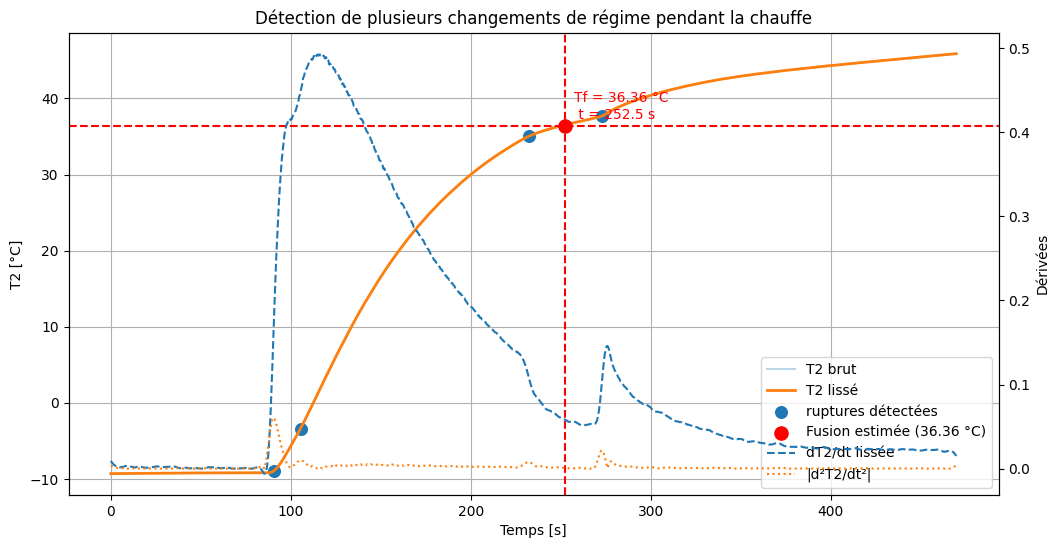

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

# --- données ---
t = df["Elapsed_Time_s"].to_numpy()
T2 = df["T2_C"].to_numpy()

# --- phase de chauffe uniquement ---
mask_heat = t < 470
t_heat = t[mask_heat]
T2_heat = T2[mask_heat]

# --- lissage de T2 ---
window = 31   # impair
poly = 3
T2_smooth = savgol_filter(T2_heat, window_length=window, polyorder=poly)

# --- dérivées ---
dT2_dt = np.gradient(T2_smooth, t_heat)
dT2_dt_smooth = savgol_filter(dT2_dt, window_length=31, polyorder=3)

d2T2_dt2 = np.gradient(dT2_dt_smooth, t_heat)
d2T2_dt2_smooth = savgol_filter(d2T2_dt2, window_length=31, polyorder=3)

# --- détection de plusieurs ruptures ---
signal_break = np.abs(d2T2_dt2_smooth)

peaks, properties = find_peaks(
    signal_break,
    prominence=np.std(signal_break),
    distance=40
)

print("Ruptures candidates :")
for k, i in enumerate(peaks, start=1):
    print(f"Rupture {k}: t = {t_heat[i]:.1f} s, T2 = {T2_smooth[i]:.2f} °C")

# --- estimation de la fusion ave### Q8. À partir de la courbe ΔT(t), relevez pour chaque transition (fusion et solidification) : le début, la fin, la durée du plateau, et la valeur maximale de |ΔT|. Présentez vos résultats dans un tableau récapitulatif.c ruptures 3 et 4 ---
if len(peaks) >= 4:
    i3 = peaks[2]
    i4 = peaks[3]

    t3, T3 = t_heat[i3], T2_smooth[i3]
    t4, T4 = t_heat[i4], T2_smooth[i4]

    t_fusion = (t3 + t4) / 2
    T_fusion = (T3 + T4) / 2

    print("\nEstimation fusion :")
    print(f"t_fusion = {t_fusion:.2f} s")
    print(f"T_fusion = {T_fusion:.2f} °C")
else:
    raise ValueError("Moins de 4 ruptures détectées : impossible d'utiliser les ruptures 3 et 4.")

# --- tracé ---
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(t_heat, T2_heat, alpha=0.3, label="T2 brut")
ax1.plot(t_heat, T2_smooth, linewidth=2, label="T2 lissé")
ax1.scatter(t_heat[peaks], T2_smooth[peaks], s=70, label="ruptures détectées")

# point fusion
ax1.scatter(t_fusion, T_fusion, color="red", s=90, zorder=5, label=f"Fusion estimée ({T_fusion:.2f} °C)")

# lignes rouges
ax1.axvline(t_fusion, color="red", linestyle="--", linewidth=1.5)
ax1.axhline(T_fusion, color="red", linestyle="--", linewidth=1.5)

# annotation
ax1.text(
    t_fusion + 5,
    T_fusion + 1,
    f"Tf = {T_fusion:.2f} °C\n t = {t_fusion:.1f} s",
    color="red"
)

ax1.set_xlabel("Temps [s]")
ax1.set_ylabel("T2 [°C]")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t_heat, dT2_dt_smooth, linestyle="--", label="dT2/dt lissée")
ax2.plot(t_heat, signal_break, linestyle=":", label="|d²T2/dt²|")
ax2.set_ylabel("Dérivées")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Détection de plusieurs changements de régime pendant la chauffe")
plt.show()

In [8]:
# max locaux
peaks_max, _ = find_peaks(df["Delta_T_smooth"], prominence=0.2, distance=100)

# min locaux
peaks_min, _ = find_peaks(-df["Delta_T_smooth"], prominence=0.2, distance=100)

print("Maxima :")
for i in peaks_max:
    print(
        f"t = {df['Elapsed_Time_s'].iloc[i]:.1f} s, "
        f"T2 = {df['T2_C'].iloc[i]:.2f} °C, "
        f"ΔT = {df['Delta_T_smooth'].iloc[i]:.2f}"
    )

print("\nMinima :")
for i in peaks_min:
    print(
        f"t = {df['Elapsed_Time_s'].iloc[i]:.1f} s, "
        f"T2 = {df['T2_C'].iloc[i]:.2f} °C, "
        f"T1 = {df['T1_C'].iloc[i]:.2f} °C, "
        f"ΔT = {df['Delta_T_smooth'].iloc[i]:.2f}"
    )

Maxima :
t = 130.3 s, T2 = 8.48 °C, ΔT = 3.09
t = 268.1 s, T2 = 37.38 °C, ΔT = 1.81
t = 662.1 s, T2 = -2.93 °C, ΔT = -0.99

Minima :
t = 230.9 s, T2 = 34.88 °C, T1 = 36.09 °C, ΔT = 1.22
t = 523.3 s, T2 = 27.13 °C, T1 = 24.01 °C, ΔT = -3.12
t = 671.5 s, T2 = -0.95 °C, T1 = -4.34 °C, ΔT = -3.06


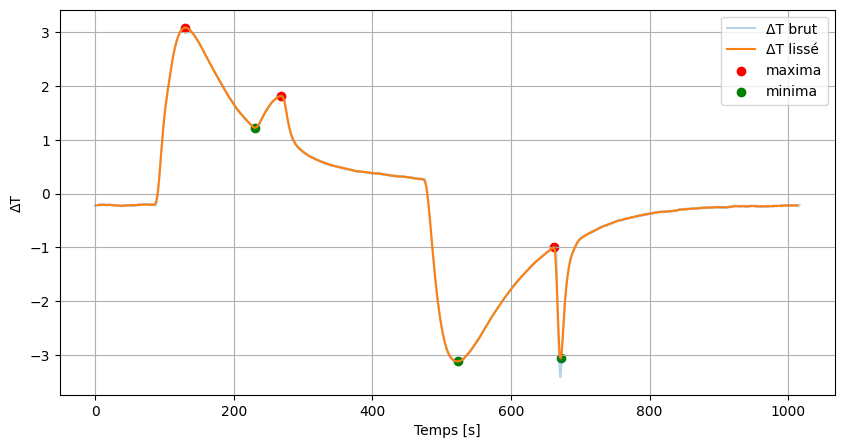

In [9]:
plt.figure(figsize=(10,5))

plt.plot(df["Elapsed_Time_s"], df["Delta_T_C"], alpha=0.3, label="ΔT brut")
plt.plot(df["Elapsed_Time_s"], df["Delta_T_smooth"], label="ΔT lissé")

plt.scatter(df["Elapsed_Time_s"].iloc[peaks_max],
            df["Delta_T_smooth"].iloc[peaks_max],
            color="red", label="maxima")

plt.scatter(df["Elapsed_Time_s"].iloc[peaks_min],
            df["Delta_T_smooth"].iloc[peaks_min],
            color="green", label="minima")

plt.xlabel("Temps [s]")
plt.ylabel("ΔT")
plt.legend()
plt.grid(True)
plt.show()

In [10]:


# Q7 - Estimation de la température de fusion
T_f_tabulee = 29.76  # °C

# Méthode à définir : plateau, moyenne locale, sélection manuelle, etc.
# Exemple :
# indices_plateau = ...
# T_f_estimee = df.loc[indices_plateau, "T2_C"].mean()

T_f_estimee = np.nan  # À remplacer
ecart_relatif = abs(T_f_estimee - T_f_tabulee) / T_f_tabulee if not np.isnan(T_f_estimee) else np.nan

print("Température de fusion estimée [°C] :", T_f_estimee)
print("Écart relatif :", ecart_relatif)


Température de fusion estimée [°C] : nan
Écart relatif : nan


**Réponse / interprétation :**

- Température de fusion estimée : ...
- Valeur tabulée : 29.76 °C
- Écart relatif : ...
- Sources d'incertitude : ...


### Q8. À partir de la courbe ΔT(t), relevez pour chaque transition (fusion et solidification) : le début, la fin, la durée du plateau, et la valeur maximale de |ΔT|. Présentez vos résultats dans un tableau récapitulatif.

**Réponse / interprétation :**

Compléter et commenter le tableau récapitulatif.


### Q9. Observez-vous un phénomène de surfusion (supercooling) lors de la solidification sur la courbe T2(t) ? Si oui, estimez son amplitude ΔT_surf et sa durée. Expliquez brièvement le mécanisme physique à l’origine de ce phénomène.

In [11]:
# Q9 - Analyse de la surfusion
# Identifier une éventuelle température de solidification inférieure à la température d'équilibre

Delta_T_surf = np.nan
duree_surf = np.nan

print("Amplitude de surfusion [°C] :", Delta_T_surf)
print("Durée de la surfusion [s] :", duree_surf)


Amplitude de surfusion [°C] : nan
Durée de la surfusion [s] : nan


**Réponse / interprétation :**

- Surfusion observée ? ...
- Amplitude : ...
- Durée : ...
- Mécanisme physique : ...


## 2.5. Estimation de la chaleur latente (question ouverte)

### Q10. En supposant une puissance de chauffe constante P, proposez et appliquez une méthode pour estimer qualitativement la chaleur latente de fusion du gallium Lf à partir de la pente de T1(t) hors transition, de la durée du plateau de fusion, et de la masse approximative de l’échantillon.

In [12]:
# Q10 - Estimation qualitative de la chaleur latente
L_f_tabulee = 80.1e3  # J/kg

# Masse de l'échantillon (à compléter avec la valeur fournie par l'assistant)
m = np.nan  # kg

# Exemple de variables à estimer
pente_T1 = np.nan           # K/s
duree_plateau_fusion = np.nan  # s

# Construire ici votre modèle / estimation
L_f_estimee = np.nan  # J/kg

print("Pente de T1 hors transition [K/s] :", pente_T1)
print("Durée du plateau de fusion [s] :", duree_plateau_fusion)
print("Chaleur latente estimée [J/kg] :", L_f_estimee)
print("Valeur tabulée [J/kg] :", L_f_tabulee)

if not np.isnan(L_f_estimee):
    print("Écart relatif :", abs(L_f_estimee - L_f_tabulee) / L_f_tabulee)


Pente de T1 hors transition [K/s] : nan
Durée du plateau de fusion [s] : nan
Chaleur latente estimée [J/kg] : nan
Valeur tabulée [J/kg] : 80100.0


**Réponse / discussion :**

- Méthode proposée : ...
- Hypothèses : ...
- Valeur estimée : ...
- Comparaison à 80.1 kJ/kg : ...
- Limites de l'approche : ...


## 3. Livrables attendus

## Checklist finale

- [ ] Toutes les cellules de code sont exécutées sans erreur
- [ ] Les graphes ont des axes, unités, titres et légendes
- [ ] Les réponses rédigées sont complétées
- [ ] Le tableau récapitulatif de la Q8 est rempli
- [ ] La discussion critique finale est ajoutée

## Rappel des données utiles

- Point de fusion du gallium : **29.76 °C**
- Chaleur latente de fusion : **80.1 kJ/kg**
- Chaleur spécifique (solide) : **0.372 J/(g.K)**
- Résolution TMP117 : **7.8 m°C**
- Précision TMP117 : **±0.1 °C**
